<a href="https://colab.research.google.com/github/24tara/Final-Year-Project-Machine-Modelling-of-Credit-Card-Approval-Predictions/blob/main/FYP_DATASET1_MODEL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data loading

In [18]:
pip install shap

In [19]:
#importing libraries that are relevant, this will allow me to manipulate data and merge tables
#renamed pandas as pd for short
import shap
import pandas as pd
import numpy as np
shap.initjs()
# matplotlib will be used for visually representing our data
import matplotlib.pyplot as plt


In [20]:
#naming my file as data
#read the csv file
data1= pd.read_csv('/content/final_cleaned_data1.csv')

In [21]:
#this is importing a library from python preparing a model for training data

from sklearn.model_selection import train_test_split

In [22]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4241 entries, 0 to 4240
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0    no_of_dependents          4241 non-null   int64  
 1    education                 4241 non-null   int64  
 2    self_employed             4241 non-null   int64  
 3    income_annum              4241 non-null   float64
 4    loan_amount               4241 non-null   float64
 5    loan_term                 4241 non-null   float64
 6    cibil_score               4241 non-null   float64
 7    residential_assets_value  4241 non-null   float64
 8    commercial_assets_value   4241 non-null   float64
 9    luxury_assets_value       4241 non-null   float64
 10   bank_asset_value          4241 non-null   float64
 11   loan_status               4241 non-null   int64  
dtypes: float64(8), int64(4)
memory usage: 397.7 KB


In [23]:
# Expand truncated values in pandas data frame
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 100)

In [24]:
data1_sample = data1.sample(frac=0.7, random_state=500)
data1_unseen = data1.drop(data1.index)

data1_sample.reset_index(drop=True, inplace=True)
data1_unseen.reset_index(drop=True, inplace=True)

print('Data for Modeling: ' + str(data1.shape))
print('Unseen Data For Predictions: ' + str(data1_unseen.shape))

Data for Modeling: (4241, 12)
Unseen Data For Predictions: (0, 12)


In [25]:
data1.columns.tolist()

[' no_of_dependents',
 ' education',
 ' self_employed',
 ' income_annum',
 ' loan_amount',
 ' loan_term',
 ' cibil_score',
 ' residential_assets_value',
 ' commercial_assets_value',
 ' luxury_assets_value',
 ' bank_asset_value',
 ' loan_status']

In [26]:
#here i am declaring my features and what my target feature is
feature_cols = [' no_of_dependents',' education',' self_employed',' income_annum',' loan_amount',' loan_term',' cibil_score',' residential_assets_value',' commercial_assets_value',' luxury_assets_value',' bank_asset_value']
X = data1[feature_cols] # Features

y = data1[' loan_status'] #target

In [27]:
#splitting the data
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3, random_state=4, stratify=y)

logisitc regression

In [28]:
# importing libraries to help build models
from sklearn.linear_model import LogisticRegression

In [29]:
#choosing a model
logreg = LogisticRegression()

In [30]:
#here i am applying the mdoel to the dataset
# x is the independent variable and y is the target varaible
logreg.fit(X_train, y_train)

LogisticRegression()

In [31]:
#this function allows my model to make predictions on the trainnig data
y_pred_train=logreg.predict(X_train)

In [32]:
#this function allows my model to make predictions on the test data
y_pred=logreg.predict(X_test)

In [33]:
#this function allows me to compare my actual data with my predicted data outputs
Comparison_df=pd.DataFrame({'Actual' : y_test,  'Predicted' : y_pred})
#this calls the comaprsion results
Comparison_df

,Actual,Predicted
2255,1,1
2516,1,1
3740,2,2
2914,1,1
1073,2,2
...,...,...
372,1,1
1764,2,2
3278,2,2
802,2,2


In [34]:
#here i am importing relevant libraries to get the accuaray score
from sklearn.metrics import accuracy_score
#i have set the a varaible called accuracy_treain to to get the accuaracy score fo my predctions made from my model
accuracy_train = accuracy_score(y_train, y_pred_train)
#ive called the code to print the accuaracy score
print ("The accuracy is: ", accuracy_train)

The accuracy is:  0.9184636118598383


In [35]:
#here i am importing relevant libraries to get the accuaray score
from sklearn.metrics import accuracy_score
#here the is a vairable called accuaracy_test, here i noticed that i had to change the names as the code abode had a varaible called accuarcy
#i changed the code above to _train and this one is _test
accuracy_test = accuracy_score(y_test, y_pred)
#ive called the code to print the accuaracy score
print ("The accuracy is: ", accuracy_test)

The accuracy is:  0.9112333071484682


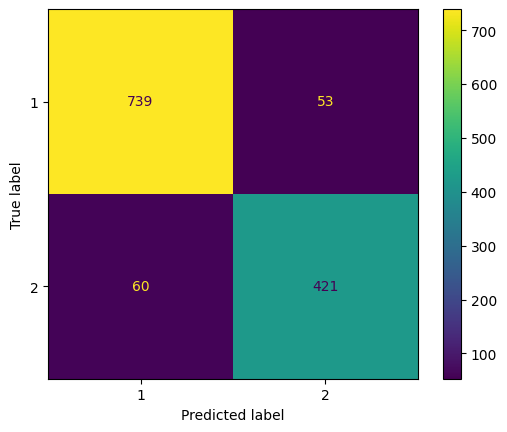

In [36]:
#here i am importing models that i can use from libraries that are relevant, the matrix and the display for it
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
#cm is a varaible for the confusion matrix
#i have then mentioned what data i want in the matrix and have said the data will equal to the amount of classes
#i have two classes
cm = confusion_matrix(y_test, y_pred, labels = logreg.classes_)
disp = ConfusionMatrixDisplay(cm, display_labels = logreg.classes_)
#ive written for it to be plotted
disp.plot()

In [37]:
#importing relavant libraries
from sklearn.metrics import classification_report
#printed the classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.92      0.93      0.93       792
           2       0.89      0.88      0.88       481

    accuracy                           0.91      1273
   macro avg       0.91      0.90      0.91      1273
weighted avg       0.91      0.91      0.91      1273



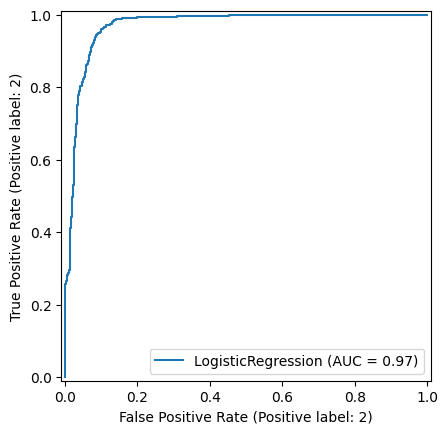

In [38]:
#importing relevant libraires
from sklearn.metrics import RocCurveDisplay
#applying the trest data to another model which is estimating the predictions
#plots
logreg = RocCurveDisplay.from_estimator(logreg, X_test, y_test)

##DECISION TREE

In [39]:
#importing relevant libraries
from sklearn.tree import DecisionTreeRegressor

In [40]:
#choosing a model
DT_regressor = DecisionTreeRegressor()
#here i am applying the mdoel to the dataset
# x is the independent variable and y is the target varaible
DT_regressor.fit(X_train, y_train)

DecisionTreeRegressor()

In [41]:
#this function allows my model to make predictions on the test data
y_pred = DT_regressor.predict(X_test)

In [42]:
#pulling libraries
from sklearn import metrics
#using different metrics
print('MAE:', metrics.mean_absolute_error(y_test, y_pred))
print('MSE:', metrics.mean_squared_error(y_test, y_pred))
print('R2:', metrics.r2_score(y_test, y_pred))

MAE: 0.029065200314218383
MSE: 0.029065200314218383
R2: 0.8763597513597514


In [43]:
#imorioting relevant libraires
from sklearn import tree
from matplotlib import pyplot as plt

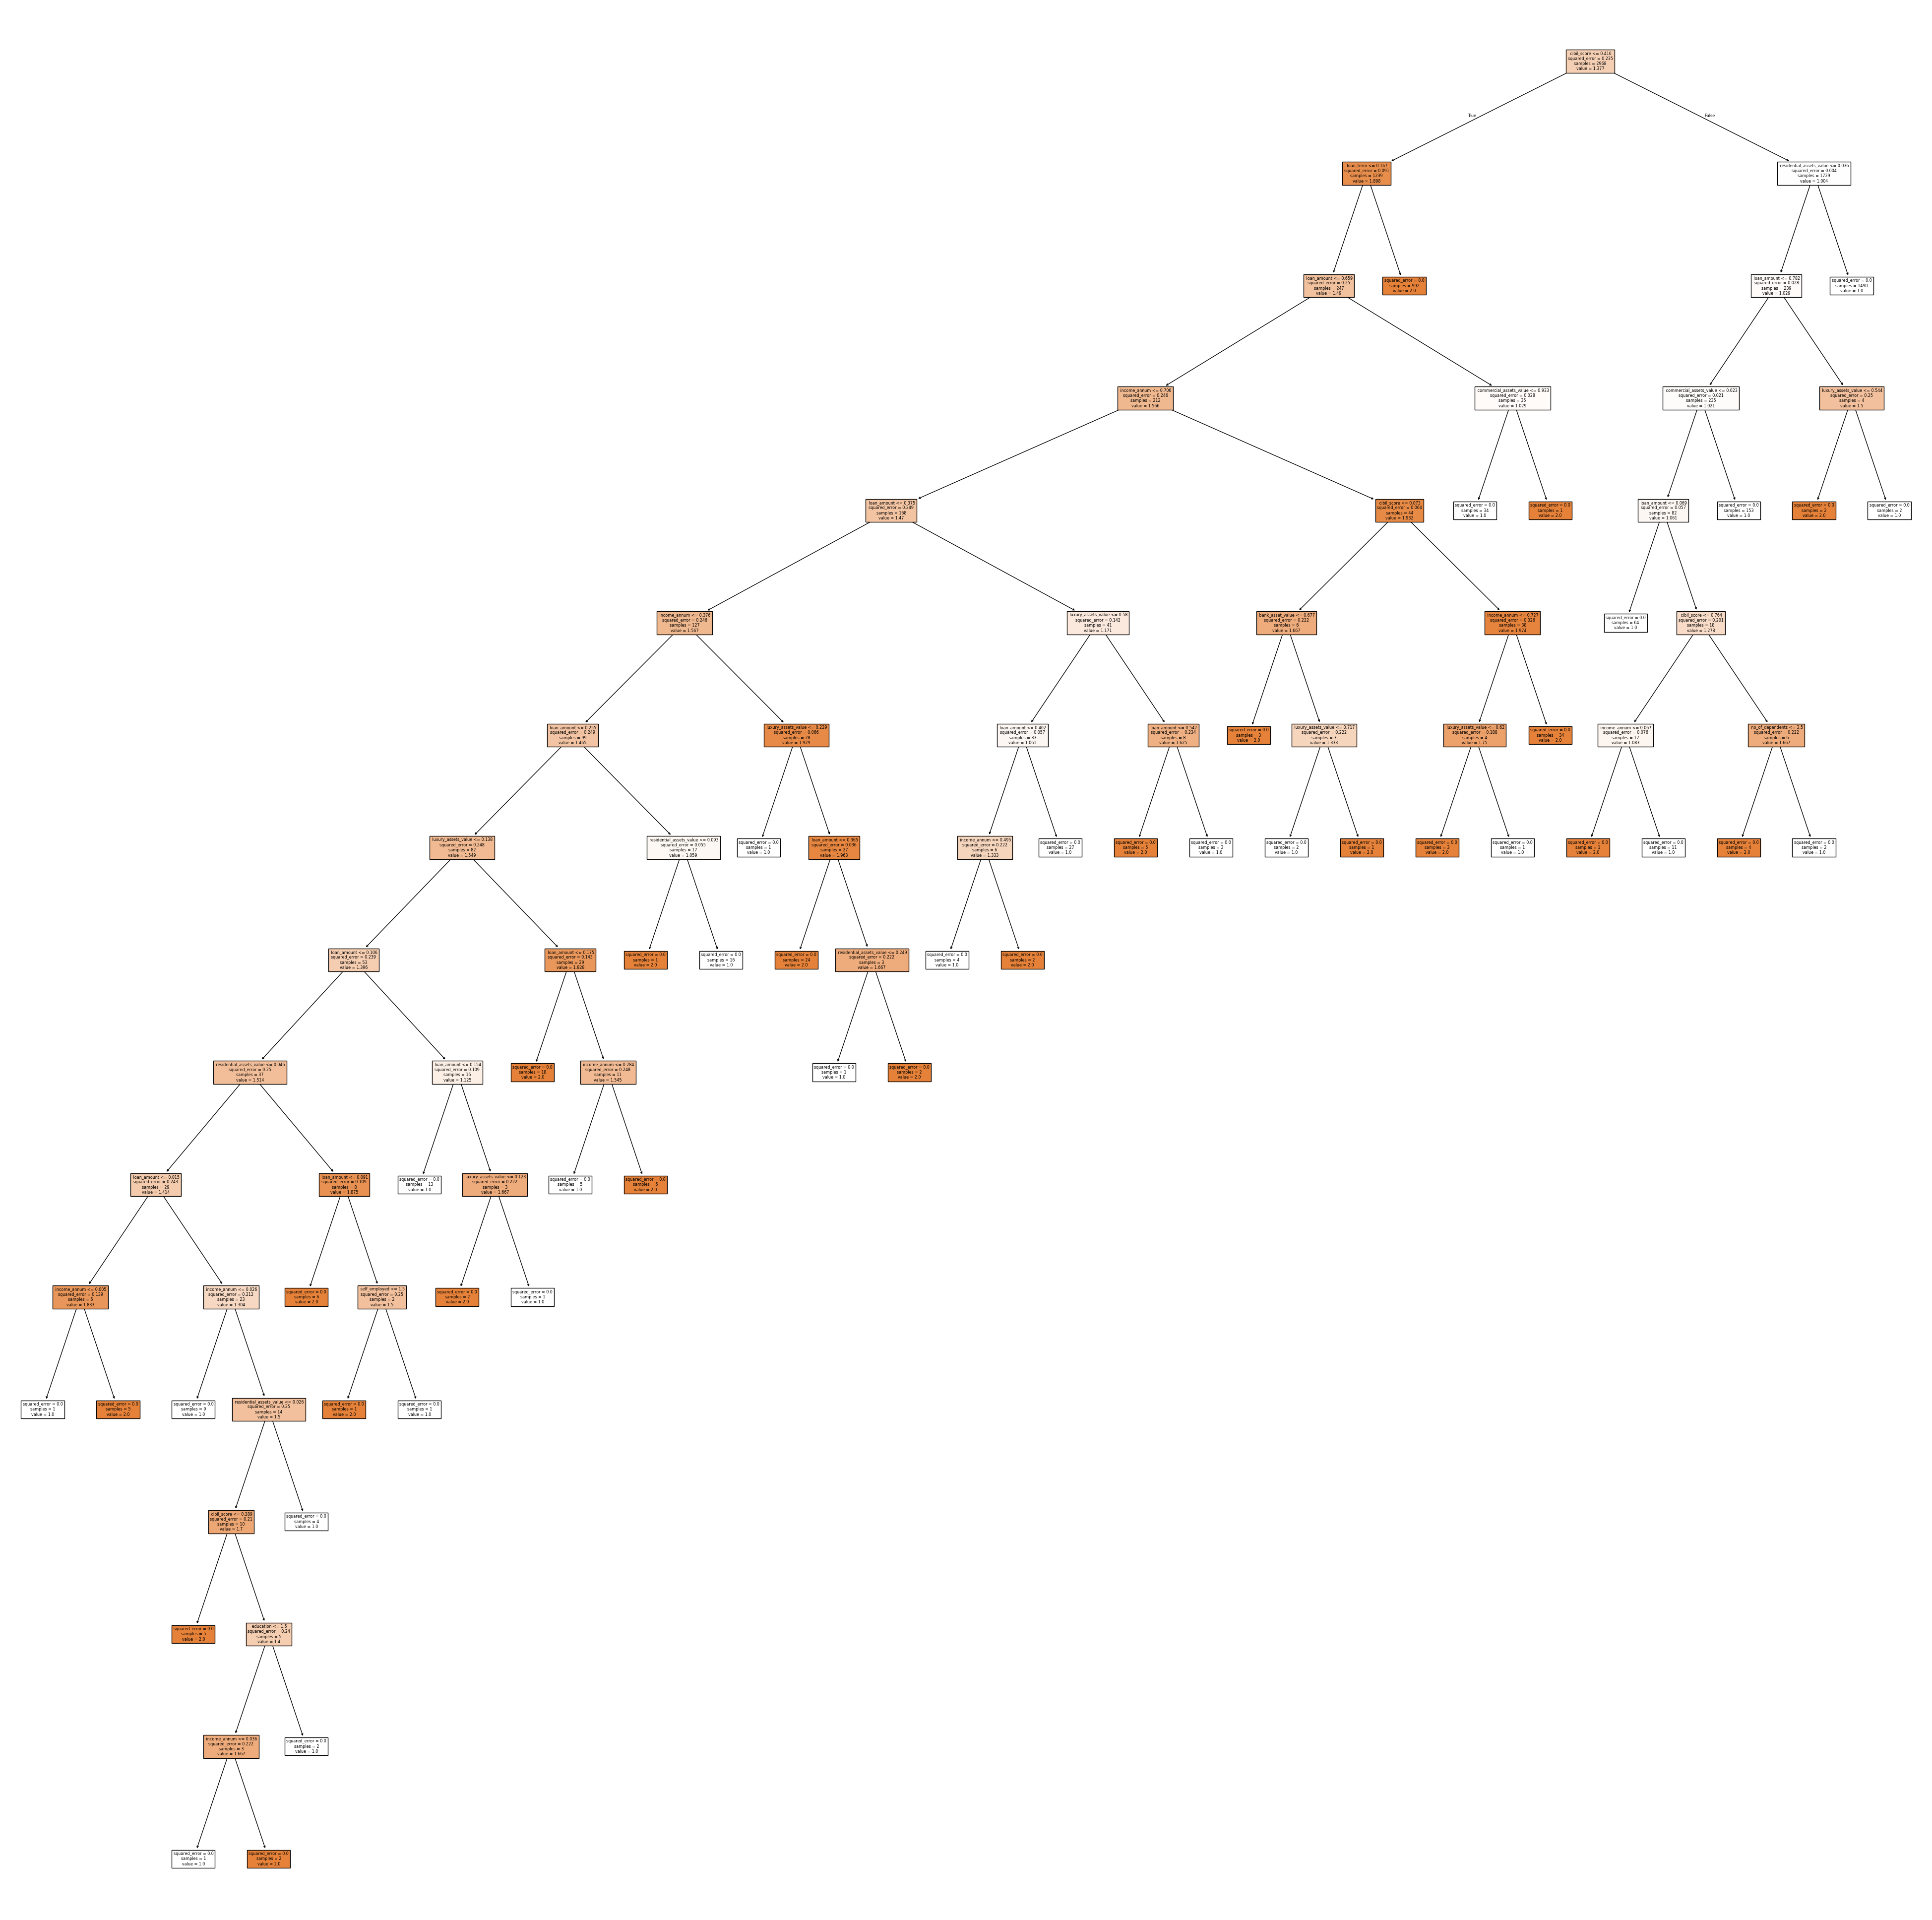

In [44]:
#width and height
Tree_figure = plt.figure(figsize=(50,50))
#plots tree that is trained
DT_Graph = tree.plot_tree(DT_regressor, feature_names=list(X_train.columns), filled=True)

In [45]:
#saves tree
Tree_figure.savefig("decistion_tree.svg")

In [46]:
#prunes the tree
DT_regressor = DecisionTreeRegressor(max_depth=4)
# fits the data
DT_regressor.fit(X_train, y_train)
y_pred = DT_regressor.predict(X_test)

In [47]:
#see pedictied results
y_pred

array([1.06097561, 1.        , 2.        , ..., 2.        , 2.        ,
       1.        ])

In [48]:
#import relevant libraries
from sklearn import metrics
#scoring metrics
print('MAE:', metrics.mean_absolute_error(y_test, y_pred))
print('MSE:', metrics.mean_squared_error(y_test, y_pred))
print('R2:', metrics.r2_score(y_test, y_pred))

MAE: 0.03933672583683122
MSE: 0.02305413467947394
R2: 0.9019301806579485


Classification report for DT
              precision    recall  f1-score   support

           1       0.98      0.97      0.98       792
           2       0.96      0.97      0.96       481

    accuracy                           0.97      1273
   macro avg       0.97      0.97      0.97      1273
weighted avg       0.97      0.97      0.97      1273

confusion_matrix for DT


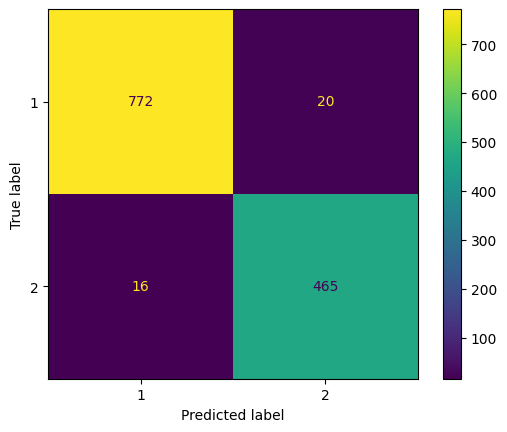

In [49]:
# import the DT algorithm, build the DT model then test it by predicting on the test data
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
dt=dt.fit(X_train,y_train)
y_pred_dt=dt.predict(X_test)

# Evaluate your DT model byt generating the classification report and the confusion matrix
from sklearn.metrics import classification_report
print("Classification report for DT")
print(classification_report(y_test,y_pred_dt))

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

print("confusion_matrix for DT")
dt_cm=confusion_matrix(y_test,y_pred_dt)
disp=ConfusionMatrixDisplay(confusion_matrix=dt_cm,display_labels=dt.classes_)
disp.plot()

RANDOM FOREST

{'n_estimators': 200}
Classification report for RF
              precision    recall  f1-score   support

           1       0.98      0.99      0.99       792
           2       0.98      0.98      0.98       481

    accuracy                           0.98      1273
   macro avg       0.98      0.98      0.98      1273
weighted avg       0.98      0.98      0.98      1273

confusion_matrix for RF


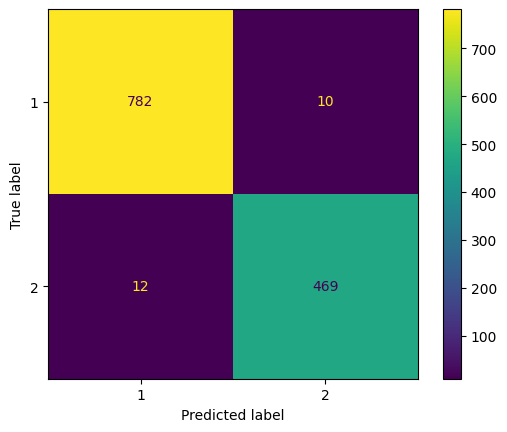

In [50]:
#create a new random forest classifier and grid search cv
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=13)

#create a dictionary of all values we want to test for n_estimators
params_rf = {'n_estimators': [50, 100, 200]}

#use gridsearch to test all values for n_estimators
rf_gs = GridSearchCV(rf, params_rf, cv=10)

#fit model to training data
rf_gs.fit(X_train, y_train)

#save best model
rf_best = rf_gs.best_estimator_

#check best n_estimators value
print(rf_gs.best_params_)

#make prediction on the test data
y_pred_rf = rf_best.predict(X_test)

# Evaluate your rf model by generating the classification report and the confusion matrix
from sklearn.metrics import classification_report
print("Classification report for RF")
print(classification_report(y_test,y_pred_rf))

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

print("confusion_matrix for RF")
rf_cm=confusion_matrix(y_test,y_pred_rf)
disp=ConfusionMatrixDisplay(confusion_matrix=rf_cm,display_labels = rf_best.classes_)
disp.plot()